# Import Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

# Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/manarabdelbaky/breast-cancer-wisconsin-diagnostic-data-set/data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Explore Dataset

In [3]:
# Shape of dataset
print("Dataset Shape:")
print(df.shape)

print("-"*40)

# Column names
print("Columns:")
print(df.columns)

print("-"*40)

# Information
df.info()

print("-"*40)

# Statistical Summary
df.describe()

Dataset Shape:
(569, 33)
----------------------------------------
Columns:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   i

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [4]:
# Missing values
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [5]:
# Remove unnecessary columns
df.drop(columns=["Unnamed: 32"], inplace=True)

# Remove ID column
df.drop(columns=["id"], inplace=True)

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [7]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [8]:
# Encode diagnosis column

encoder = LabelEncoder()

df["diagnosis"] = encoder.fit_transform(df["diagnosis"])

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [10]:
# Features
X = df.drop("diagnosis", axis=1)

# Target
y = df["diagnosis"]

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (455, 30)
Testing Samples  : (114, 30)


In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# EDA

In [13]:
# Count values of diagnosis
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

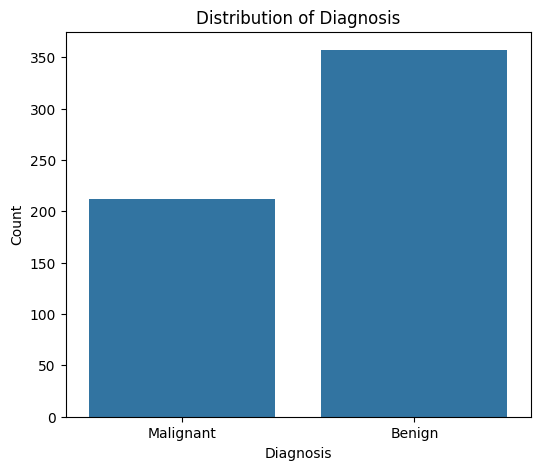

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=df["diagnosis"].map({0:"Benign",1:"Malignant"})
)

plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

In [15]:
diagnosis_percentage = df["diagnosis"].value_counts(normalize=True)*100

print(diagnosis_percentage)

diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64


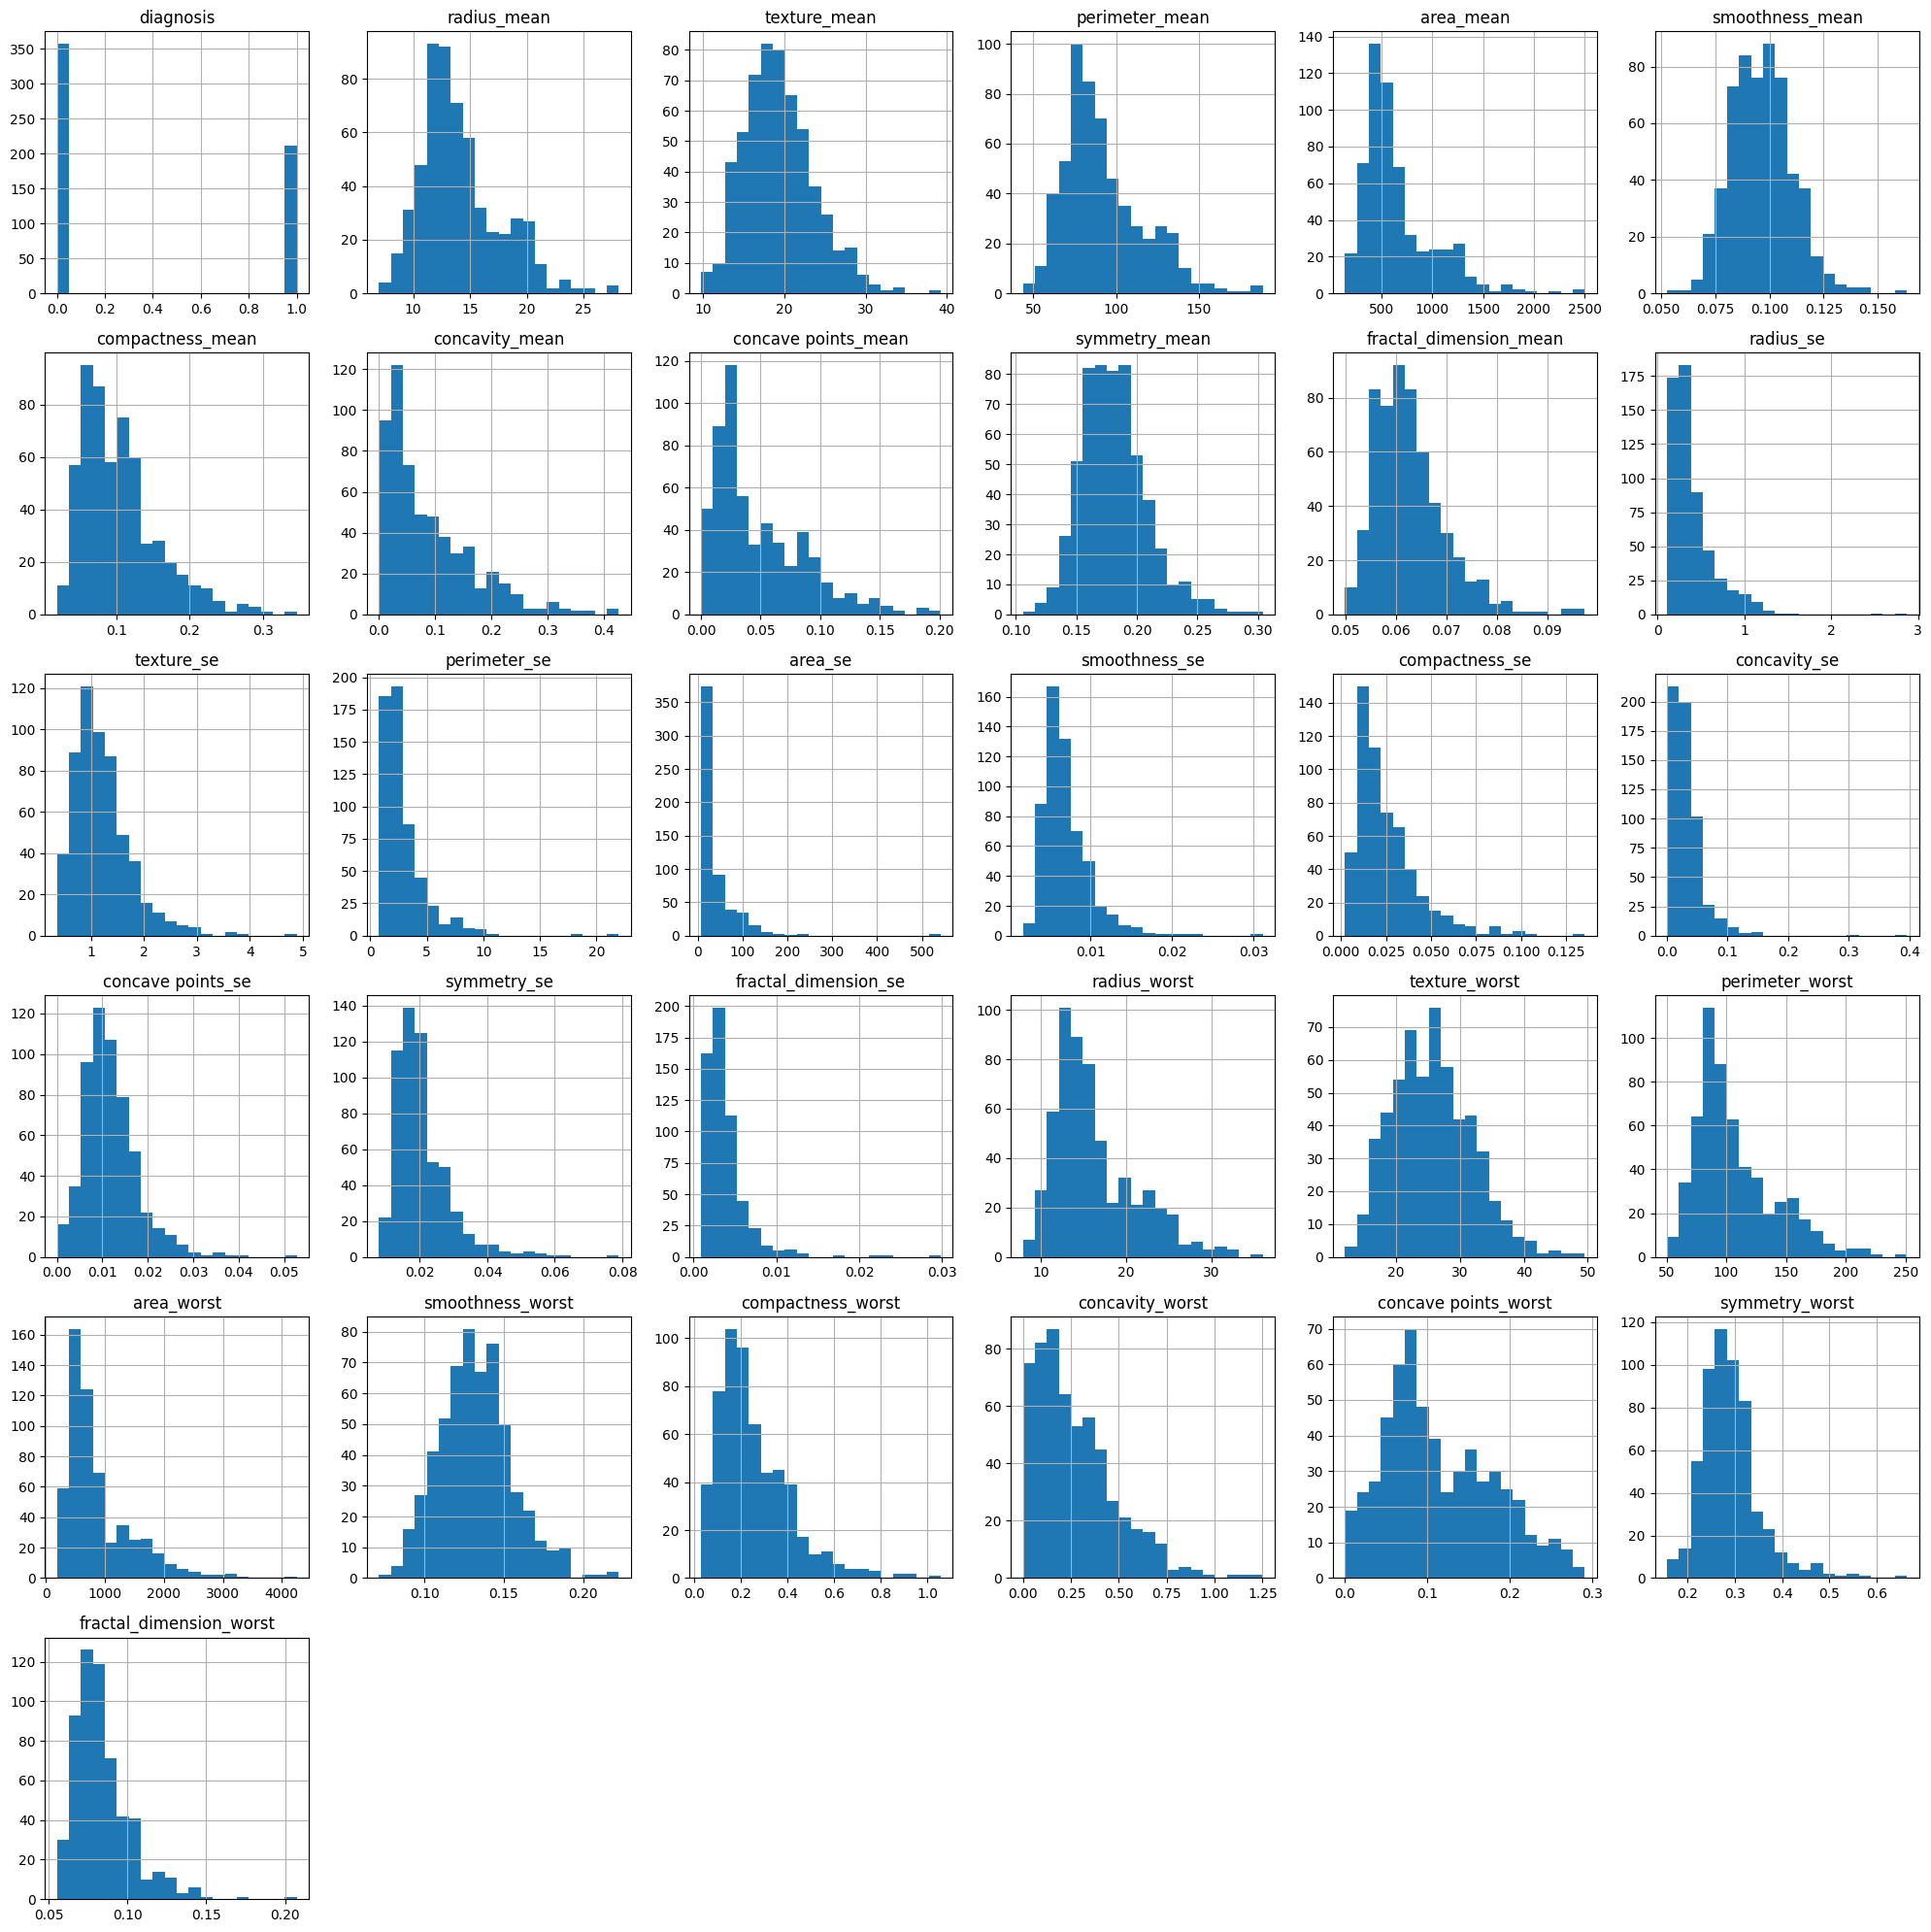

In [16]:
df.hist(figsize=(20,20), bins=20)

plt.tight_layout()

plt.show()

In [17]:
corr = df.corr()

corr

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


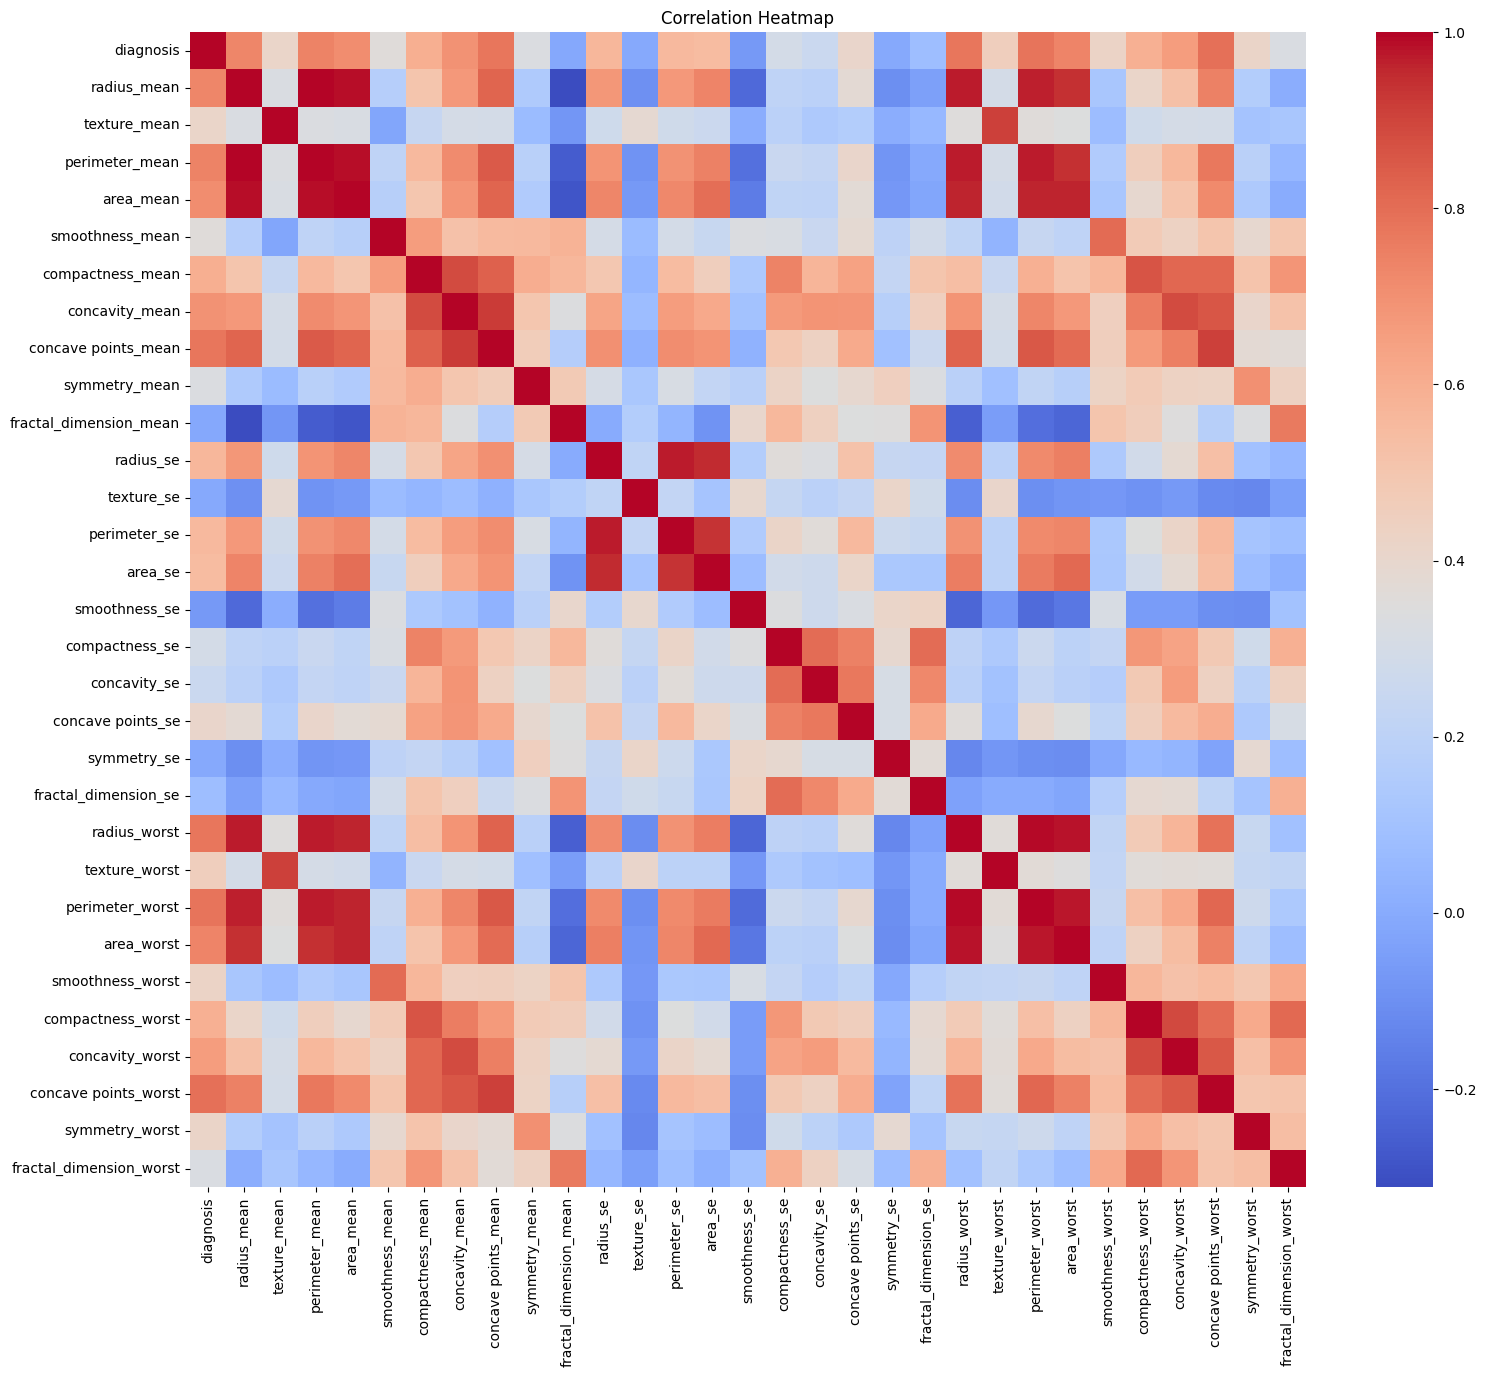

In [18]:
plt.figure(figsize=(18,15))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
#Correlation with Target
corr_target = corr["diagnosis"].sort_values(ascending=False)

corr_target

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

In [20]:
# Top Positive Correlations
corr_target.head(15)

diagnosis               1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
compactness_mean        0.596534
compactness_worst       0.590998
radius_se               0.567134
perimeter_se            0.556141
Name: diagnosis, dtype: float64

In [21]:
#Top Negative Correlations
corr_target.tail(15)

texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0.006522
texture_se                -0.008303
fractal_dimension_mean    -0.012838
smoothness_se             -0.067016
Name: diagnosis, dtype: float64

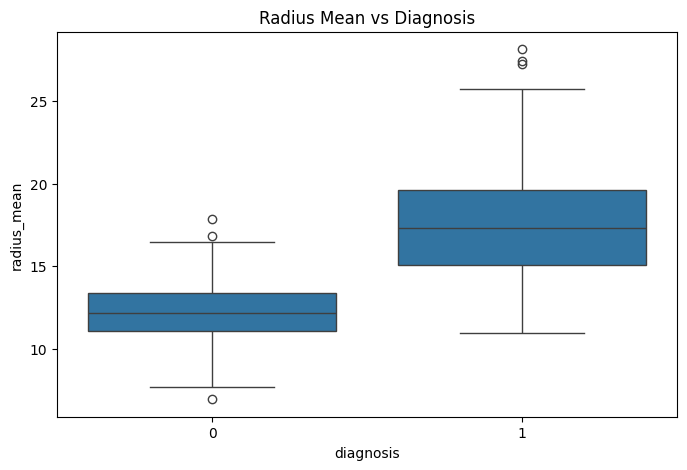

In [22]:
#Boxplot (Radius Mean)
plt.figure(figsize=(8,5))

sns.boxplot(
    x="diagnosis",
    y="radius_mean",
    data=df
)

plt.title("Radius Mean vs Diagnosis")

plt.show()

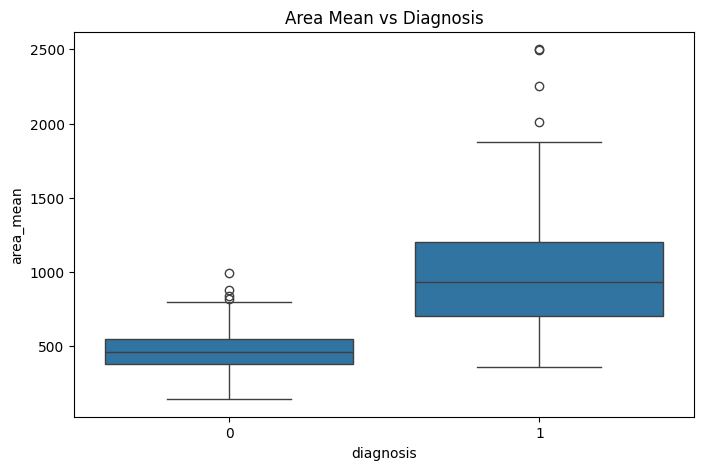

In [23]:
# Boxplot (Area Mean)
plt.figure(figsize=(8,5))

sns.boxplot(
    x="diagnosis",
    y="area_mean",
    data=df
)

plt.title("Area Mean vs Diagnosis")

plt.show()

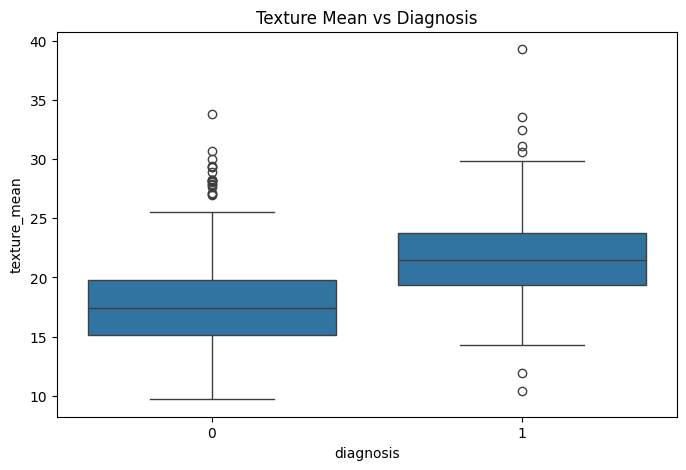

In [24]:
#Boxplot (Texture Mean)
plt.figure(figsize=(8,5))

sns.boxplot(
    x="diagnosis",
    y="texture_mean",
    data=df
)

plt.title("Texture Mean vs Diagnosis")

plt.show()

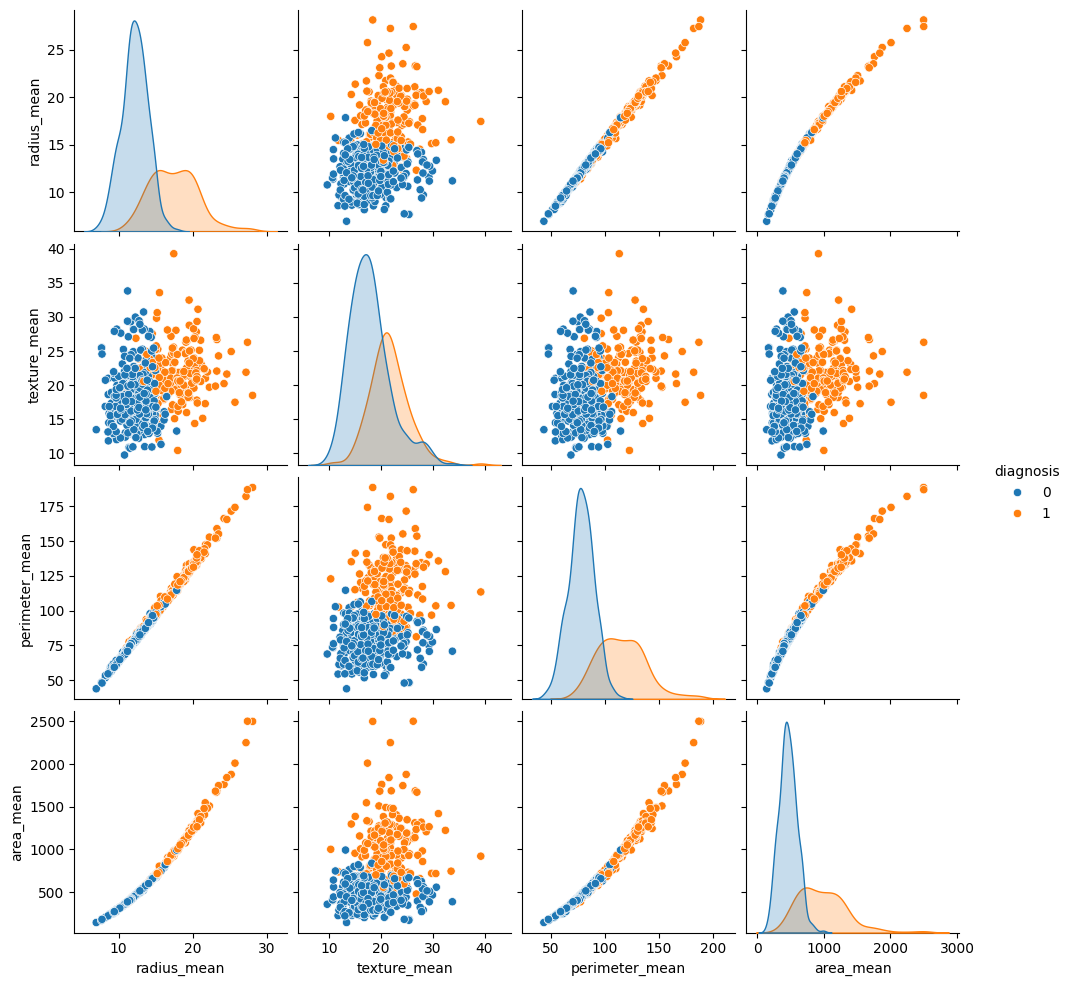

In [25]:
selected_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "diagnosis"
]

sns.pairplot(
    df[selected_features],
    hue="diagnosis"
)

plt.show()

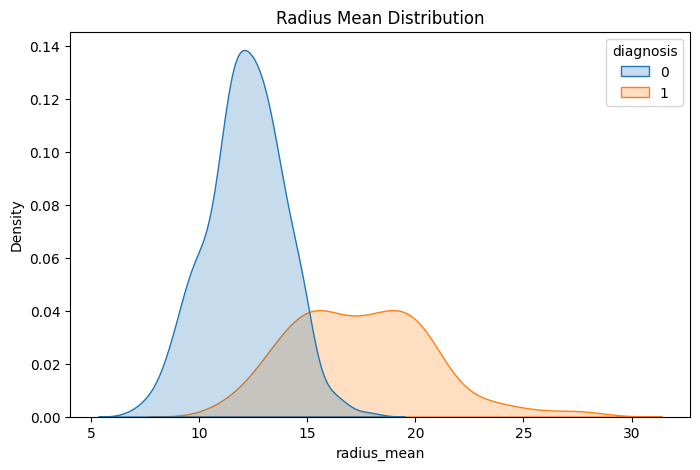

In [26]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="radius_mean",
    hue="diagnosis",
    fill=True
)

plt.title("Radius Mean Distribution")

plt.show()

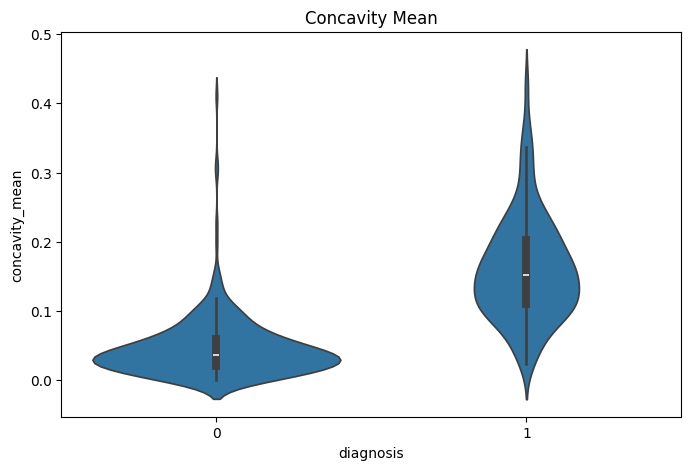

In [27]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x="diagnosis",
    y="concavity_mean",
    data=df
)

plt.title("Concavity Mean")

plt.show()

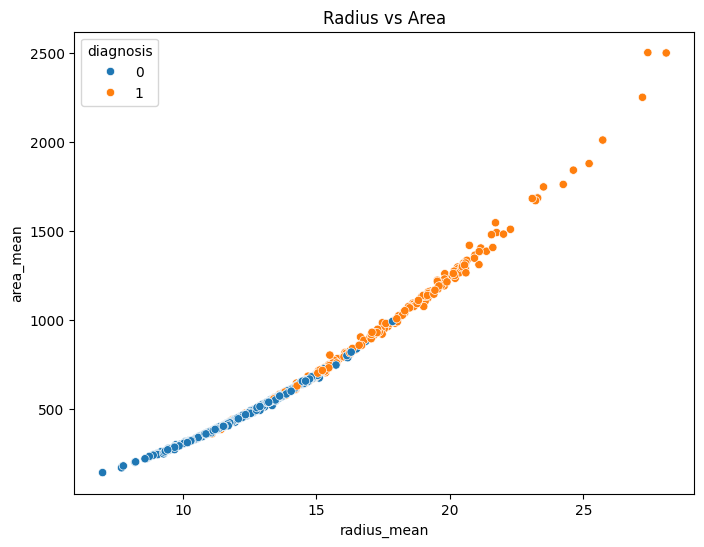

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="radius_mean",
    y="area_mean",
    hue="diagnosis",
    data=df
)

plt.title("Radius vs Area")

plt.show()

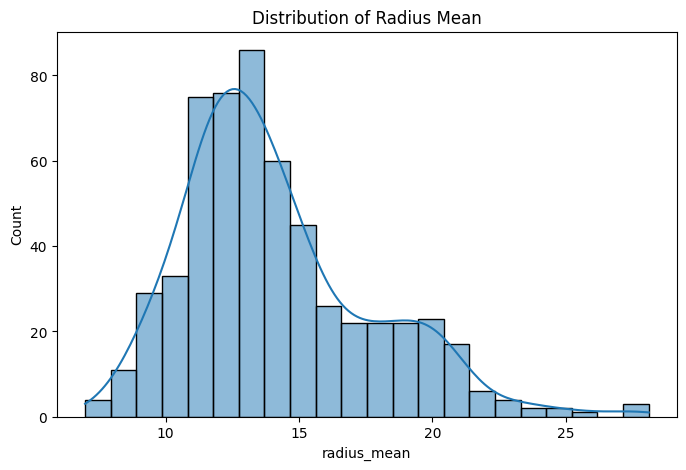

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="radius_mean",
    kde=True
)

plt.title("Distribution of Radius Mean")

plt.show()

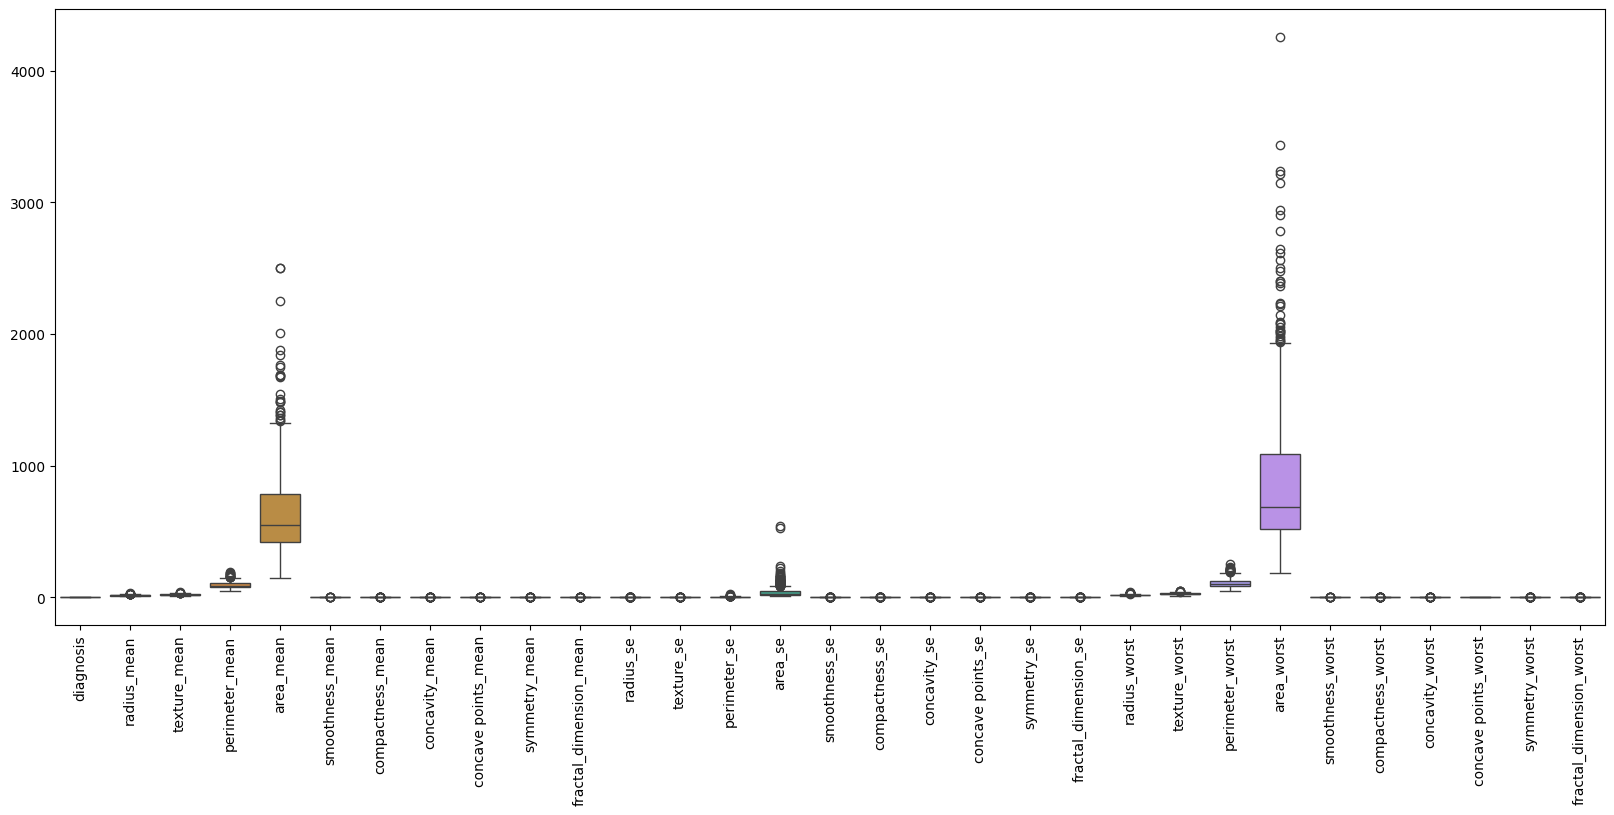

In [30]:
plt.figure(figsize=(20,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

# Create Models

## Train Logistic Regression

In [31]:
# Create Logistic Regression model
lr = LogisticRegression(random_state=42)

# Train the model
lr.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy:", lr_accuracy)

Accuracy: 0.9649122807017544


## Logistic Regression Evaluation

In [32]:
from sklearn.metrics import classification_report
import pandas as pd
from IPython.display import display

# Convert report to DataFrame
report = classification_report(
    y_test,
    lr_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Display colored table
display(
    report_df.style
        .background_gradient(cmap="RdYlGn", subset=["precision", "recall", "f1-score"])
        .background_gradient(cmap="Blues", subset=["support"])
        .format({
            "precision": "{:.2f}",
            "recall": "{:.2f}",
            "f1-score": "{:.2f}",
            "support": "{:.0f}"
        })
        .set_caption(" Logistic Regression Classification Report")
)

,precision,recall,f1-score,support
0,0.96,0.99,0.97,72
1,0.97,0.93,0.95,42
accuracy,0.96,0.96,0.96,1
macro avg,0.97,0.96,0.96,114
weighted avg,0.97,0.96,0.96,114


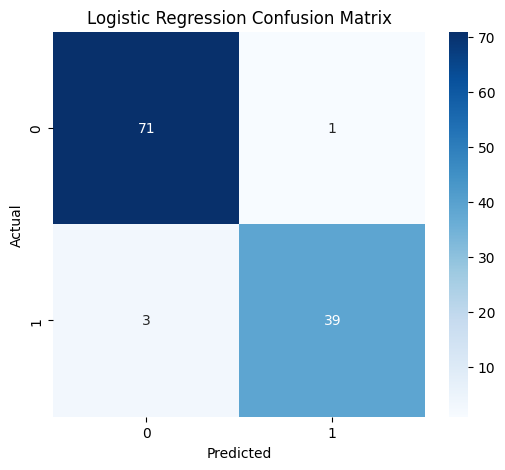

In [33]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Train KNN

In [34]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("Accuracy:", knn_accuracy)

Accuracy: 0.956140350877193


## KNN Evaluation

In [35]:
from sklearn.metrics import classification_report
import pandas as pd
from IPython.display import display

# Convert report to DataFrame
report = classification_report(
    y_test,
    knn_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Display colored table
display(
    report_df.style
        .background_gradient(cmap="RdYlGn", subset=["precision", "recall", "f1-score"])
        .background_gradient(cmap="Blues", subset=["support"])
        .format({
            "precision": "{:.2f}",
            "recall": "{:.2f}",
            "f1-score": "{:.2f}",
            "support": "{:.0f}"
        })
        .set_caption(" KNN Classification Report")
)

,precision,recall,f1-score,support
0,0.95,0.99,0.97,72
1,0.97,0.90,0.94,42
accuracy,0.96,0.96,0.96,1
macro avg,0.96,0.95,0.95,114
weighted avg,0.96,0.96,0.96,114


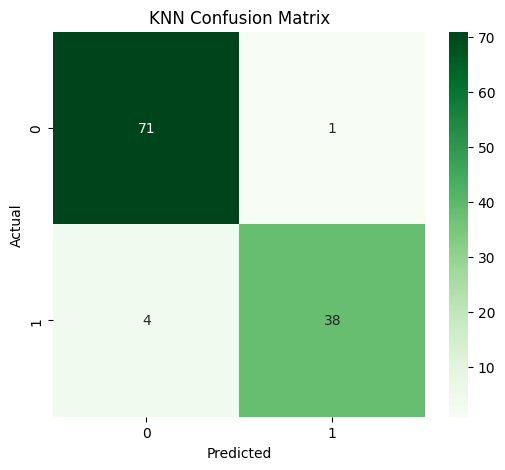

In [36]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Train Decision Tree

In [37]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Accuracy:", dt_accuracy)

Accuracy: 0.9298245614035088


## Decision Tree Evaluation

In [38]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



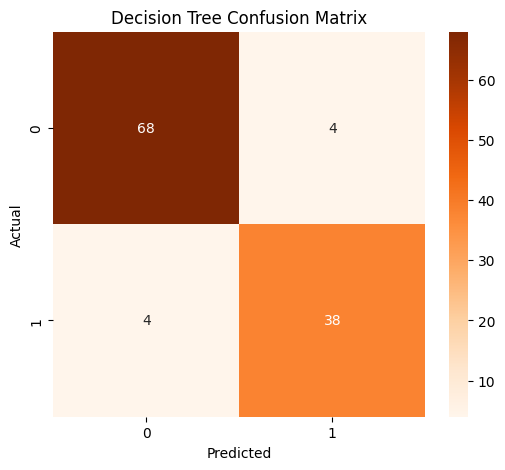

In [39]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Train Random Forest

In [40]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy:", rf_accuracy)

Accuracy: 0.9736842105263158


## Random Forest Evaluation

In [41]:
from sklearn.metrics import classification_report
import pandas as pd
from IPython.display import display

# Convert report to DataFrame
report = classification_report(
    y_test,
    rf_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Display colored table
display(
    report_df.style
        .background_gradient(cmap="RdYlGn", subset=["precision", "recall", "f1-score"])
        .background_gradient(cmap="Blues", subset=["support"])
        .format({
            "precision": "{:.2f}",
            "recall": "{:.2f}",
            "f1-score": "{:.2f}",
            "support": "{:.0f}"
        })
        .set_caption(" Random Forest Classification Report")
)

,precision,recall,f1-score,support
0,0.96,1.00,0.98,72
1,1.00,0.93,0.96,42
accuracy,0.97,0.97,0.97,1
macro avg,0.98,0.96,0.97,114
weighted avg,0.97,0.97,0.97,114


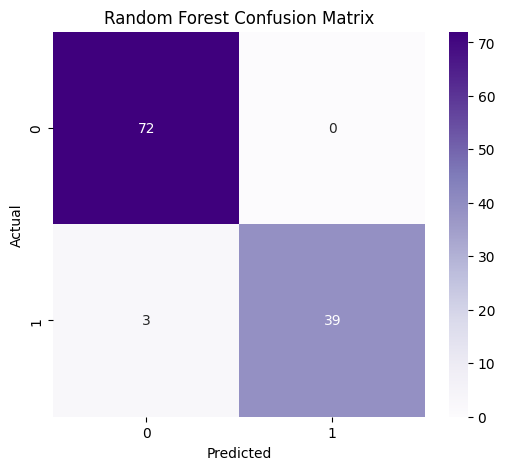

In [42]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Train SVM

In [43]:
svm = SVC(probability=True, random_state=42)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("Accuracy:", svm_accuracy)

Accuracy: 0.9736842105263158


## SVM Evaluation

In [44]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



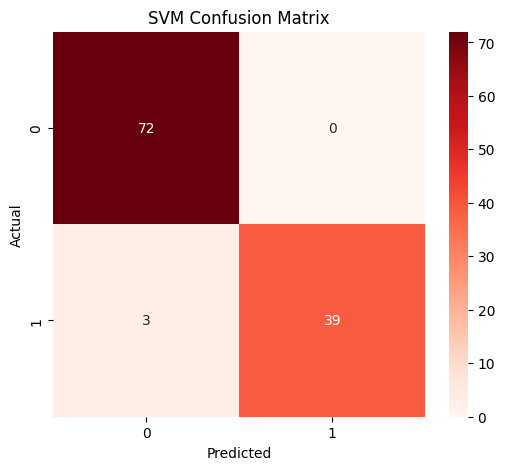

In [45]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Compare All Models

In [46]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],

    "Accuracy":[
        lr_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy
    ]

})

results.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results

,Model,Accuracy
4,SVM,0.973684
3,Random Forest,0.973684
0,Logistic Regression,0.964912
1,KNN,0.956140
2,Decision Tree,0.929825


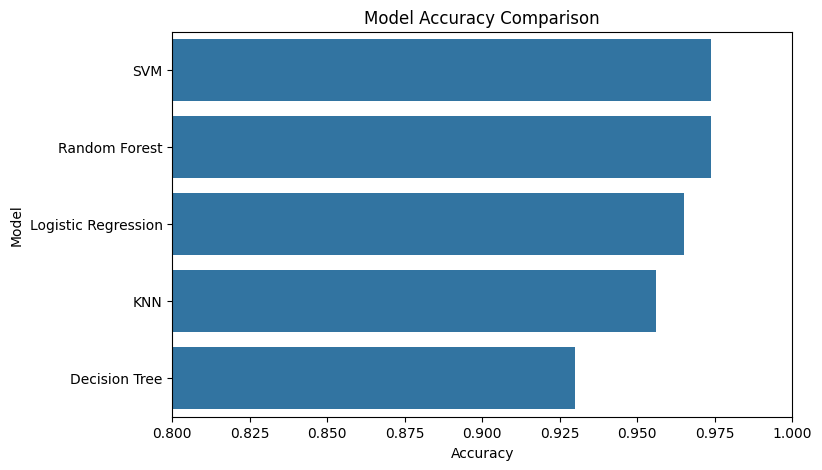

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")

plt.xlim(0.8,1)

plt.show()

In [48]:
# Best Model
print(results.iloc[0])

Model            SVM
Accuracy    0.973684
Name: 4, dtype: object


## ROC Curve

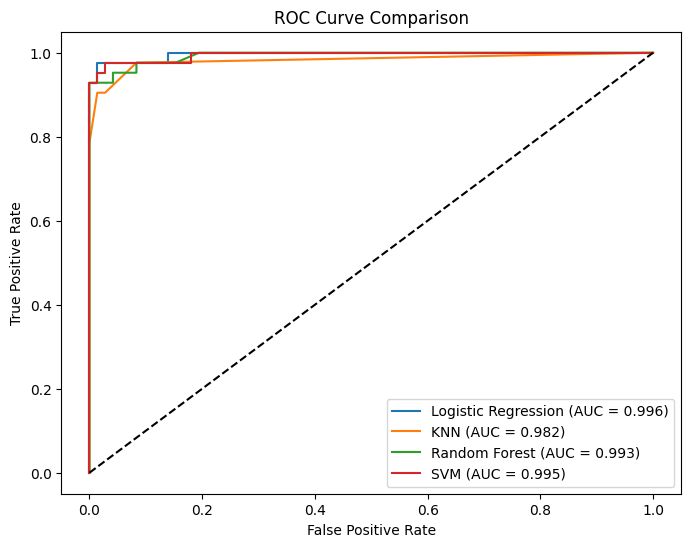

In [49]:
plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr,
    "KNN": knn,
    "Random Forest": rf,
    "SVM": svm
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

## Predict New Patient 

In [50]:
# Select a sample
sample = X.iloc[[0]]

# Scale the sample
sample_scaled = scaler.transform(sample)

# Predict using the best model (SVM)
prediction = svm.predict(sample_scaled)

if prediction[0] == 1:
    print("Prediction: Malignant Tumor")
else:
    print("Prediction: Benign Tumor")

Prediction: Malignant Tumor
